На основе подготовленной таблицы данных HeadHunter нужно создать 6 архитектур нейросетей, проверить разные гиперпараметры и сравнить результат.

Используются только числовые признаки. Текстовые поля в модель не подаются.


In [1]:
import re

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler

from tensorflow.keras import utils
from tensorflow.keras.layers import Activation, BatchNormalization, Dense, Dropout, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, RMSprop

%matplotlib inline


In [2]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l10/hh_fixed.csv'
DATA_FILE = 'hh_fixed.csv'

gdown.download(DATA_URL, DATA_FILE, quiet=True)

df = pd.read_csv(DATA_FILE, index_col=0)

# Проверяем размер таблицы и первые строки
print(df.shape)
df.head(3)


(62967, 12)


,"Пол, возраст",ЗП,Ищет работу на должность:,Город,Занятость,График,Опыт (двойное нажатие для полной версии),Последенее/нынешнее место работы,Последеняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 29 лет , родился 16 мая 1989",40000 руб.,Специалист по поддержке чата(support team) дом...,"Новороссийск , готов к переезду (Анапа, Геленд...",полная занятость,полный день,Опыт работы 3 года 9 месяцев Специалист по по...,"ООО ""Гольфстрим""",Генеральный директор,Высшее образование 2011 Международный юридиче...,26.04.2019 08:04,Не указано
1,"Мужчина , 38 лет , родился 25 мая 1980",40000 руб.,Системный администратор,"Новосибирск , м. Березовая роща , не готов к ...",полная занятость,полный день,Опыт работы 11 лет 11 месяцев Системный админ...,ООО «Завод модульных технологий»,Системный администратор,Высшее образование 2002 Новосибирский государс...,26.04.2019 04:30,Не указано
2,"Мужчина , 35 лет , родился 14 июня 1983",300000 руб.,DevOps TeamLead / DevOps архитектор,"Москва , готов к переезду , готов к редким ком...",полная занятость,полный день,Опыт работы 12 лет 11 месяцев DevOps TeamLead...,Банк ВТБ (ПАО),Начальник отдела методологии разработки (DevOp...,DevOps TeamLead / DevOps архитектор 300 000 ру...,09.04.2019 14:40,Не указано


In [3]:
# Получаем номера нужных столбцов
columns = {name: df.columns.get_loc(name) for name in df.columns}

COL_SEX_AGE = columns['Пол, возраст']
COL_SALARY = columns['ЗП']
COL_POS_SEEK = columns['Ищет работу на должность:']
COL_POS_PREV = columns['Последеняя/нынешняя должность']
COL_CITY = columns['Город']
COL_EMPL = columns['Занятость']
COL_SCHED = columns['График']
COL_EXP = columns['Опыт (двойное нажатие для полной версии)']
COL_EDU = columns['Образование и ВУЗ']
COL_UPDATED = columns['Обновление резюме']


In [4]:
def normalize_text(value):
    if not isinstance(value, str):
        return ''
    return value.replace('\n', ' ').replace('\xa0', '').strip().lower()


# Извлекаем год из даты формата дд.мм.гггг
def get_year(value):
    match = re.search(r'\d\d\.\d\d\.(\d{4})', normalize_text(value))
    return int(match.group(1)) if match else 0


In [5]:
# Курсы валют нужны для приведения зарплаты к рублям
currency_rate = {
    'usd': 65.,
    'kzt': 0.17,
    'грн': 2.6,
    'белруб': 30.5,
    'eur': 70.,
    'kgs': 0.9,
    'сум': 0.007,
    'azn': 37.5,
}

# Границы классов для возраста и опыта
age_class = [0, [18, 23, 28, 33, 38, 43, 48, 53, 58, 63]]
experience_class = [0, [7, 13, 25, 37, 61, 97, 121, 157, 193, 241]]

# Справочники категориальных признаков
city_class = [0, {
    'москва': 0,
    'санкт-петербург': 1,
    'новосибирск': 2,
    'екатеринбург': 2,
    'нижний новгород': 2,
    'казань': 2,
    'челябинск': 2,
    'омск': 2,
    'самара': 2,
    'ростов-на-дону': 2,
    'уфа': 2,
    'красноярск': 2,
    'пермь': 2,
    'воронеж': 2,
    'волгоград': 2,
    'прочие города': 3,
}]

employment_class = [0, {
    'стажировка': 0,
    'частичная занятость': 1,
    'проектная работа': 2,
    'полная занятость': 3,
}]

schedule_class = [0, {
    'гибкий график': 0,
    'полный день': 1,
    'сменный график': 2,
    'удаленная работа': 3,
    'вахтовый метод': 4,
}]

education_class = [0, {
    'высшее': 0,
    'среднее специальное': 1,
    'неоконченное высшее': 2,
}]


In [6]:
# Заполняем количество классов для каждого справочника
def fill_class_sizes(*class_groups):
    for class_group in class_groups:
        values = class_group[1]
        class_group[0] = len(values) + 1 if isinstance(values, list) else max(values.values()) + 1


fill_class_sizes(
    age_class,
    experience_class,
    city_class,
    employment_class,
    schedule_class,
    education_class,
)


In [7]:
# Перевод числового значения
def value_to_ohe(value, class_group):
    borders = class_group[1]
    class_count = class_group[0]

    for class_id, border in enumerate(borders):
        if value < border:
            break
    else:
        class_id = class_count - 1

    return utils.to_categorical(class_id, class_count)


In [8]:
def text_to_flags(value, class_group):
    text = normalize_text(value)
    result = np.zeros(class_group[0])

    for marker, class_id in class_group[1].items():
        if marker in text:
            result[class_id] = 1.

    return result


In [9]:
# Базовый год чтобы по нему вычислить возраст из года рождения
BASE_YEAR = 2019


def split_sex_age(value):
    text = normalize_text(value)

    sex = 1. if 'муж' in text else 0.

    year_match = re.search(r'\d{4}', text)
    age = BASE_YEAR - int(year_match.group(0)) if year_match else 0

    return sex, age


In [10]:
def age_to_vector(age):
    return value_to_ohe(age, age_class)


def experience_to_vector(months):
    return value_to_ohe(months, experience_class)


# Зарплату приводим к рублям и делим на 1000
def parse_salary(value):
    text = normalize_text(value)
    number = re.search(r'\d+', text)

    if not number:
        return 0.

    salary = float(number.group(0))

    for currency, rate in currency_rate.items():
        if currency in text:
            salary *= rate
            break

    return salary / 1000.

def parse_city(value):
    text = normalize_text(value)
    class_count = city_class[0]

    for word in re.split(r'[ ,.:()?!]', text):
        class_id = city_class[1].get(word)
        if class_id is not None:
            break
    else:
        class_id = class_count - 1

    return utils.to_categorical(class_id, class_count)

def parse_employment(value):
    return text_to_flags(value, employment_class)


def parse_schedule(value):
    return text_to_flags(value, schedule_class)


def parse_education(value):
    result = text_to_flags(value, education_class)

    if result[2] > 0.:
        result[0] = 0.

    return result


# Опыт переводим в месяцы, годы * 12 + отдельные месяцы
def parse_experience(value):
    text = normalize_text(value)

    years_match = re.search(r'(\d+)\s+(год.?|лет)', text)
    months_match = re.search(r'(\d+)\s+месяц', text)

    years = int(years_match.group(1)) if years_match else 0
    months = int(months_match.group(1)) if months_match else 0

    return years * 12 + months


In [11]:
def row_to_sample(row):
    sex, age = split_sex_age(row[COL_SEX_AGE])
    experience_months = parse_experience(row[COL_EXP])

    features = np.hstack([
        np.array([sex]),
        age_to_vector(age),
        parse_city(row[COL_CITY]),
        parse_employment(row[COL_EMPL]),
        parse_schedule(row[COL_SCHED]),
        parse_education(row[COL_EDU]),
        experience_to_vector(experience_months),
    ])

    target = np.array([parse_salary(row[COL_SALARY])])
    return features, target

def make_dataset(rows):
    features, targets = [], []

    for row in rows:
        x_row, y_row = row_to_sample(row)
        if y_row[0] > 0:
            features.append(x_row)
            targets.append(y_row)

    return np.array(features), np.array(targets)


In [12]:
x_train_01, y_train = make_dataset(df.values)

print(x_train_01.shape)
print(y_train.shape)

sample_id = 0
print(x_train_01[sample_id])
print(y_train[sample_id])


(62967, 39)
(62967, 1)
[1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.
 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
[40.]


In [13]:
def draw_mae(history, title=''):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history['mae'], label='обучающая выборка')
    plt.plot(history.history['val_mae'], label='проверочная выборка')
    plt.title(title)
    plt.xlabel('Эпоха')
    plt.ylabel('MAE')
    plt.legend()
    plt.grid()
    plt.show()


def compile_and_train(model, optimizer, batch_size=32, epochs=30):
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    return model.fit(
        x_train_01,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        verbose=0,
    )


def show_final_mae(history, model_number):
    value = history.history['val_mae'][-1]
    print(f'Модель {model_number} готова. Финальная ошибка MAE на валидации: {value}')


Модель 1 готова. Финальная ошибка MAE на валидации: 31.401012420654297


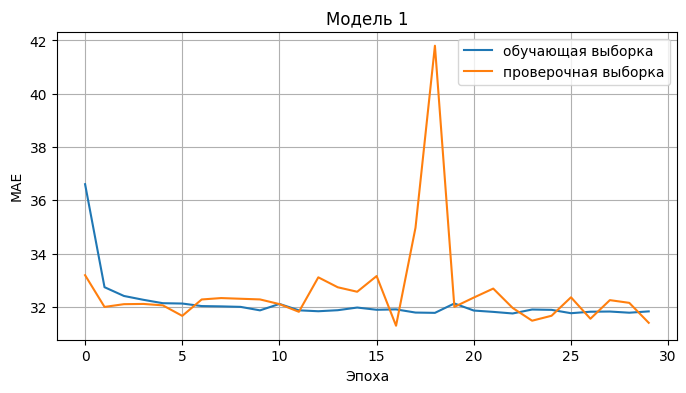

In [14]:
# простая полносвязная сеть
model_1 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear'),
])

history_1 = compile_and_train(
    model_1,
    optimizer=Adam(learning_rate=0.001),
    batch_size=32,
    epochs=30,
)

show_final_mae(history_1, 1)
draw_mae(history_1, 'Модель 1')


Модель 2 готова. Финальная ошибка MAE на валидации: 31.721275329589844


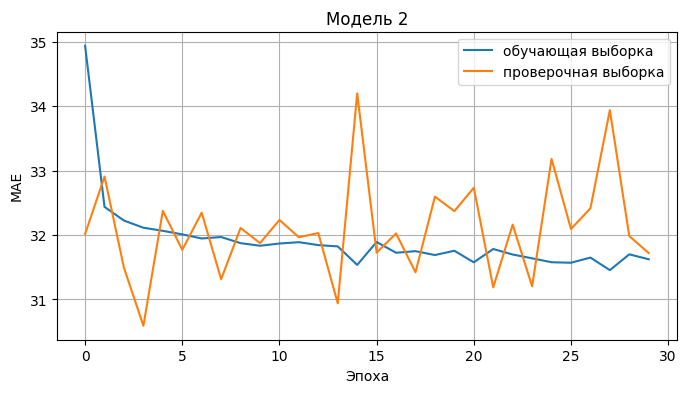

In [15]:
# глубокая сеть
model_2 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(8, activation='relu'),
    Dense(1, activation='linear'),
])

history_2 = compile_and_train(
    model_2,
    optimizer=Adam(learning_rate=0.001),
    batch_size=32,
    epochs=30,
)

show_final_mae(history_2, 2)
draw_mae(history_2, 'Модель 2')


Модель 3 готова. Финальная ошибка MAE на валидации: 31.113737106323242


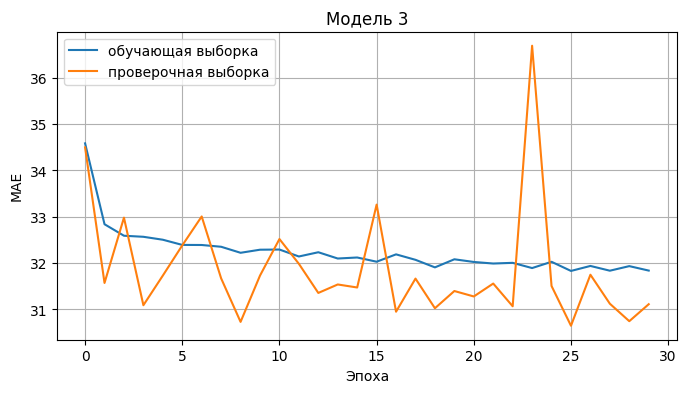

In [16]:
# сеть с Dropout
model_3 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(1, activation='linear'),
])

history_3 = compile_and_train(
    model_3,
    optimizer=Adam(learning_rate=0.001),
    batch_size=32,
    epochs=30,
)

show_final_mae(history_3, 3)
draw_mae(history_3, 'Модель 3')


Модель 4 готова. Финальная ошибка MAE на валидации: 31.908370971679688


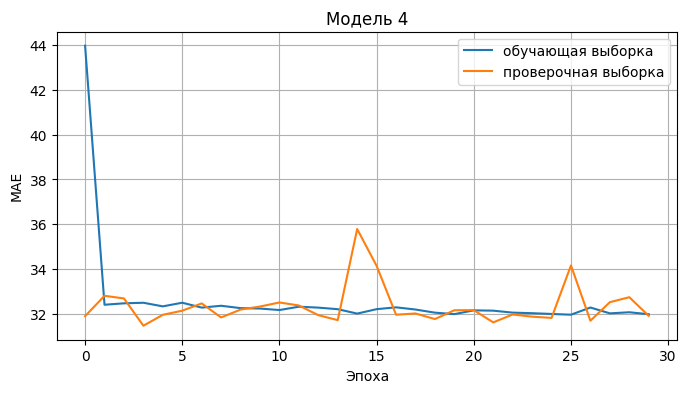

In [17]:
# сеть с BatchNormalization
model_4 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dense(1, activation='linear'),
])

history_4 = compile_and_train(
    model_4,
    optimizer=Adam(learning_rate=0.001),
    batch_size=32,
    epochs=30,
)

show_final_mae(history_4, 4)
draw_mae(history_4, 'Модель 4')


Модель 5 готова. Финальная ошибка MAE на валидации: 31.993206024169922


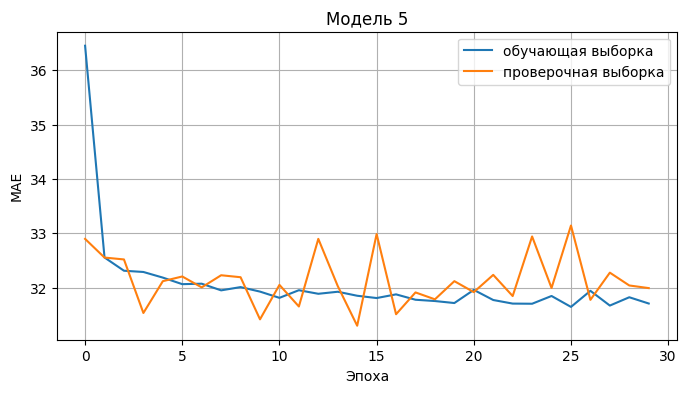

In [18]:
# широкая сеть с большим числом нейронов
model_5 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(512, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1, activation='linear'),
])

history_5 = compile_and_train(
    model_5,
    optimizer=Adam(learning_rate=0.0005),
    batch_size=64,
    epochs=30,
)

show_final_mae(history_5, 5)
draw_mae(history_5, 'Модель 5')


Модель 6 готова. Финальная ошибка MAE на валидации: 31.54580307006836


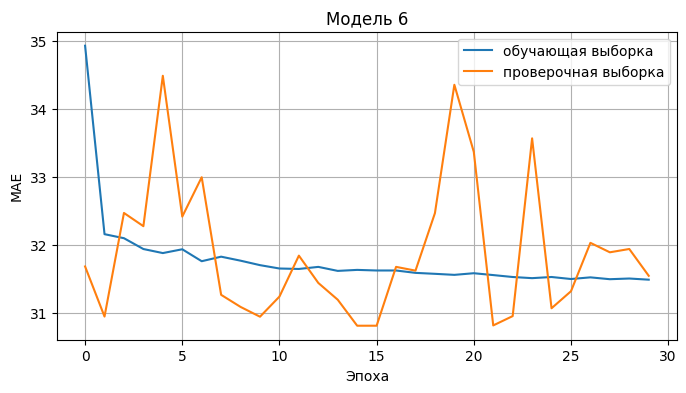

In [19]:
# используется активация ELU
model_6 = Sequential([
    Input(shape=(x_train_01.shape[1],)),
    Dense(128, activation='elu'),
    Dense(64, activation='elu'),
    Dense(32, activation='elu'),
    Dense(1, activation='linear'),
])

history_6 = compile_and_train(
    model_6,
    optimizer=RMSprop(learning_rate=0.001),
    batch_size=32,
    epochs=30,
)

show_final_mae(history_6, 6)
draw_mae(history_6, 'Модель 6')
